# 隨機目標生成與周圍點座標計算器 (Target & Surrounding Points Generator)

本 Notebook 示範如何：
1. 於指定的經緯度範圍內，隨機生成約 **100** 個目標點。
2. 計算每個目標點於 **每 10 度** 方位角（0°, 10°, ..., 350°）且距離目標 **隨機 5-15 公里** 的經緯度座標。
3. 將計算結果輸出為 CSV 檔案 `surrounding_coordinates.csv`。
4. 欄位包含：目標編號 (`target_id`)、目標緯度 (`target_latitude`)、目標經度 (`target_longitude`)、角度 (`angle`)、生成的緯度 (`generated_latitude`)、生成的經度 (`generated_longitude`) 與距離 (`distance_km`)。

### 1. 環境設定與匯入套件
我們將 `src/` 目錄加入到系統路徑中，以便能夠直接載入 `ship_navigator` 模組。

In [1]:
import sys
import csv
from pathlib import Path

# 將 src/ 目錄加入 sys.path 以便匯入 ship_navigator
sys.path.insert(0, str(Path.cwd() / 'src'))

from ship_navigator import generate_random_targets, generate_randomized_surrounding_points

### 2. 設定參數
設定隨機目標個數、經緯度生成邊界、方位角間隔與隨機距離範圍。

In [2]:
# --- 參數設定 ---
NUM_TARGETS = 100        # 目標點個數
BEARING_STEP = 10        # 方位角間隔 (每 10 度)
MIN_DIST_KM = 5.0        # 最小距離 (km)
MAX_DIST_KM = 15.0       # 最大距離 (km)

# 經緯度範圍設定 (預設為台灣周邊海域範圍)
LAT_MIN, LAT_MAX = 22.0, 25.0
LON_MIN, LON_MAX = 119.0, 122.0

OUTPUT_CSV_PATH = 'surrounding_coordinates.csv'

print(f'將在 緯度 [{LAT_MIN}, {LAT_MAX}], 經度 [{LON_MIN}, {LON_MAX}] 隨機生成 {NUM_TARGETS} 個目標點...')

將在 緯度 [22.0, 25.0], 經度 [119.0, 122.0] 隨機生成 100 個目標點...


### 3. 生成目標點與計算周圍點座標
隨機生成目標，並使用大圓公式與隨機距離，計算各目標 36 個方位角（每10度）的對應經緯度。

In [3]:
# 1. 隨機生成 100 個目標
targets = generate_random_targets(
    num_targets=NUM_TARGETS,
    lat_min=LAT_MIN,
    lat_max=LAT_MAX,
    lon_min=LON_MIN,
    lon_max=LON_MAX
)

# 2. 計算每個目標的周圍點座標
results = []
for idx, target in enumerate(targets, start=1):
    # 對於每一個目標點，計算每 10 度的隨機距離點
    points = generate_randomized_surrounding_points(
        center_coord=target,
        bearing_step=BEARING_STEP,
        min_dist_km=MIN_DIST_KM,
        max_dist_km=MAX_DIST_KM
    )
    
    for pt in points:
        results.append({
            'target_id': idx,
            'target_latitude': target.latitude,
            'target_longitude': target.longitude,
            'angle': pt.bearing,
            'generated_latitude': pt.coordinate.latitude,
            'generated_longitude': pt.coordinate.longitude,
            'distance_km': pt.distance_km
        })

print(f'成功生成 {NUM_TARGETS} 個目標點！')
print(f'已計算 {len(results)} 個周圍方位角座標點（每個目標點有 {360 // BEARING_STEP} 個方向的周圍點）。')

成功生成 100 個目標點！
已計算 3600 個周圍方位角座標點（每個目標點有 36 個方向的周圍點）。


### 4. 輸出至 CSV 檔案
將欄位 `target_id`, `target_latitude`, `target_longitude`, `angle`, `generated_latitude`, `generated_longitude`, `distance_km` 寫入 CSV 檔案。

In [4]:
# 3. 輸出成 CSV 檔
with open(OUTPUT_CSV_PATH, mode='w', newline='', encoding='utf-8-sig') as csv_file:
    fieldnames = ['target_id', 'target_latitude', 'target_longitude', 'angle', 'generated_latitude', 'generated_longitude', 'distance_km']
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    
    writer.writeheader()
    for row in results:
        writer.writerow(row)
        
print(f'結果已成功儲存至: {Path(OUTPUT_CSV_PATH).resolve()}')

結果已成功儲存至: /Users/jesse/Documents/python/dist_cal/surrounding_coordinates.csv


### 5. 資料預覽
展示產生的 CSV 資料前 10 筆預覽。

In [5]:
# 4. 預覽 CSV 內容與基本統計
print('CSV 檔案前 10 筆資料預覽：')
h_id = '目標編號'
h_t_loc = '目標經緯度 (Lat, Lon)'
h_ang = '角度 (°)'
h_g_loc = '生成經緯度 (Lat, Lon)'
h_dist = '距離 (km)'
print(f'{h_id:<6} | {h_t_loc:<25} | {h_ang:<8} | {h_g_loc:<25} | {h_dist:<8}')
print('-' * 80)
for row in results[:10]:
    target_loc = f'{row["target_latitude"]:.4f}, {row["target_longitude"]:.4f}'
    gen_loc = f'{row["generated_latitude"]:.4f}, {row["generated_longitude"]:.4f}'
    print(f'{row["target_id"]:<8} | {target_loc:<25} | {row["angle"]:<8.1f} | {gen_loc:<25} | {row["distance_km"]:<8.2f}')
print('... (其餘省略) ...')

CSV 檔案前 10 筆資料預覽：
目標編號   | 目標經緯度 (Lat, Lon)          | 角度 (°)   | 生成經緯度 (Lat, Lon)          | 距離 (km) 
--------------------------------------------------------------------------------
1        | 23.8763, 121.1916         | 0.0      | 23.9936, 121.1916         | 13.04   
1        | 23.8763, 121.1916         | 10.0     | 23.9264, 121.2012         | 5.66    
1        | 23.8763, 121.1916         | 20.0     | 23.9507, 121.2212         | 8.81    
1        | 23.8763, 121.1916         | 30.0     | 23.9333, 121.2276         | 7.32    
1        | 23.8763, 121.1916         | 40.0     | 23.9738, 121.2812         | 14.16   
1        | 23.8763, 121.1916         | 50.0     | 23.9418, 121.2770         | 11.33   
1        | 23.8763, 121.1916         | 60.0     | 23.9218, 121.2778         | 10.13   
1        | 23.8763, 121.1916         | 70.0     | 23.9179, 121.3168         | 13.54   
1        | 23.8763, 121.1916         | 80.0     | 23.8918, 121.2879         | 9.95    
1        | 23.8763, 121.1916     

### 6. 結果視覺化
使用 `matplotlib` 繪製地圖分布，展示 100 個隨機目標點的分佈情形，並隨機選取 3 個目標點畫出圍繞的星狀虛線連線。

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32239 (\N{CJK UNIFIED IDEOGRAPH-7DEF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32147 (\N{CJK UNIFIED IDEOGRAPH-7D93}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


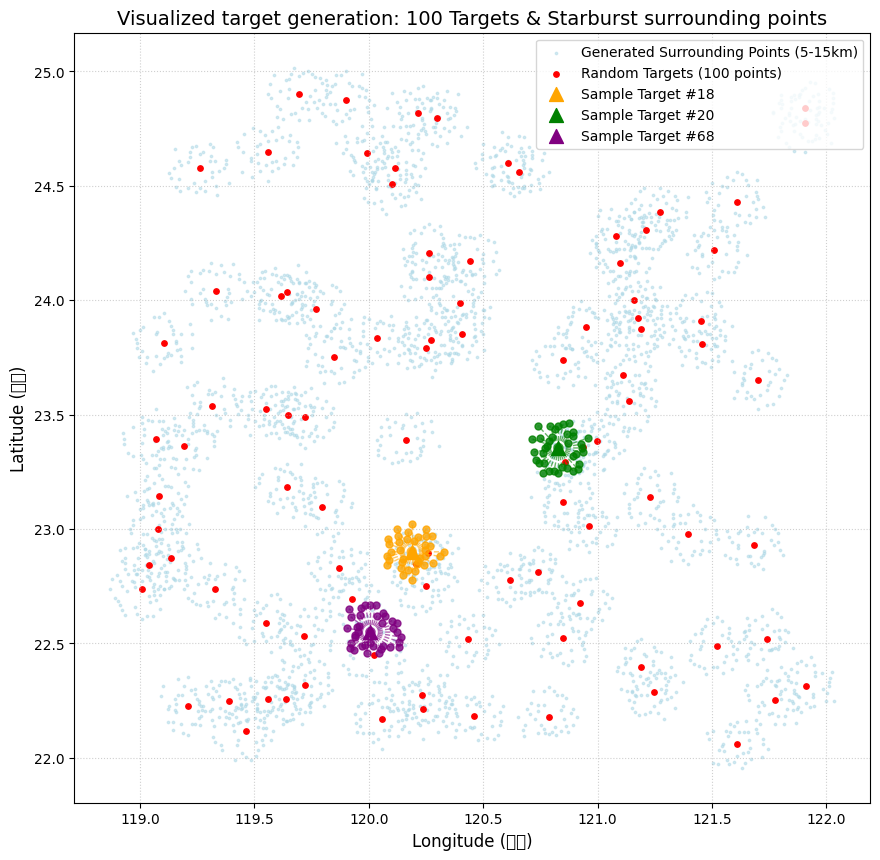

In [6]:
try:
    import matplotlib.pyplot as plt
    
    # 繪製所有目標與周圍點
    plt.figure(figsize=(12, 10))
    
    # 1. 繪製所有生成的周圍點與目標點
    target_lats = [t.latitude for t in targets]
    target_lons = [t.longitude for t in targets]
    
    gen_lats = [r['generated_latitude'] for r in results]
    gen_lons = [r['generated_longitude'] for r in results]
    
    plt.scatter(gen_lons, gen_lats, color='lightblue', s=3, alpha=0.5, label='Generated Surrounding Points (5-15km)')
    plt.scatter(target_lons, target_lats, color='red', marker='o', s=15, label='Random Targets (100 points)')
    
    # 2. 隨機選取 3 個目標，將其與周圍的 36 個點用虛線相連，以便視覺化方位
    sample_ids = random.sample(range(1, NUM_TARGETS + 1), min(3, NUM_TARGETS))
    colors = ['orange', 'green', 'purple']
    for i, sid in enumerate(sample_ids):
        sample_rows = [r for r in results if r['target_id'] == sid]
        if sample_rows:
            c_lon = sample_rows[0]['target_longitude']
            c_lat = sample_rows[0]['target_latitude']
            lbl = f'Sample Target #{sid}'
            plt.scatter([c_lon], [c_lat], color=colors[i], marker='^', s=100, label=lbl)
            for row in sample_rows:
                plt.plot([c_lon, row['generated_longitude']], [c_lat, row['generated_latitude']], color=colors[i], linestyle='--', alpha=0.6, linewidth=1)
                plt.scatter([row['generated_longitude']], [row['generated_latitude']], color=colors[i], s=25, alpha=0.8)
                
    plt.title(f'Visualized target generation: {NUM_TARGETS} Targets & Starburst surrounding points', fontsize=14)
    plt.xlabel('Longitude (經度)', fontsize=12)
    plt.ylabel('Latitude (緯度)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()
except ImportError:
    print('請先安裝 matplotlib 以進行繪圖：pip install matplotlib 或 uv add matplotlib')